In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

customers = pd.read_csv('olist_customers_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')
geo = pd.read_csv('olist_geolocation_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')


In [47]:
print("\n--- KIỂM TRA TÍNH TOÀN VẸN CỦA ORDER_ID ---")
# Kiểm tra số lượng order_id có trong items nhưng KHÔNG CÓ trong orders
missing_orders = order_items[~order_items['order_id'].isin(orders['order_id'])]
num_missing = missing_orders['order_id'].nunique()
print(f"Số lượng order_id duy nhất tồn tại trong bảng 'order_items' nhưng KHÔNG tồn tại trong bảng 'orders' là: {num_missing}")


--- KIỂM TRA TÍNH TOÀN VẸN CỦA ORDER_ID ---
Số lượng order_id duy nhất tồn tại trong bảng 'order_items' nhưng KHÔNG tồn tại trong bảng 'orders' là: 0


==> Các bảng đã được chuẩn hóa với các khóa chính và khóa ngoại rất rõ ràng. Việc join các bảng không lo bị trùng lặp dữ liệu

In [48]:
# Dịch tên danh mục sản phẩm sang tiếng Anh để dễ phân tích
products = pd.merge(products, category_translation, on='product_category_name', how='left')

# Chuyển đổi các cột thời gian trong bảng orders và reviews sang định dạng datetime
time_cols_orders = ['order_purchase_timestamp', 'order_approved_at', 
                    'order_delivered_carrier_date', 'order_delivered_customer_date', 
                    'order_estimated_delivery_date']
for col in time_cols_orders:
    orders[col] = pd.to_datetime(orders[col])

time_cols_reviews = ['review_creation_date', 'review_answer_timestamp']
for col in time_cols_reviews:
    reviews[col] = pd.to_datetime(reviews[col])

order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

# Xem thông tin tổng quan của bảng Orders
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [49]:
df_master = orders.merge(order_items, on='order_id', how='left')
df_master = df_master.merge(products, on='product_id', how='left')
df_master = df_master.merge(payments, on='order_id', how='left')
df_master = df_master.merge(customers, on='customer_id', how='left')
df_master = df_master.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

print(f"Kích thước bảng dữ liệu tổng hợp: {df_master.shape}")

Kích thước bảng dữ liệu tổng hợp: (119143, 32)


In [50]:
df_master

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,housewares,1.0,credit_card,1.0,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,housewares,3.0,voucher,1.0,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,housewares,2.0,voucher,1.0,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,perfumery,1.0,boleto,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,auto,1.0,credit_card,3.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119138,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1.0,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,baby,1.0,credit_card,3.0,195.00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,4.0
119139,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1.0,b80910977a37536adeddd63663f916ad,...,home_appliances_2,1.0,credit_card,5.0,271.01,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,5.0
119140,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1.0,d1c427060a0f73f6b889a5c7c61f2ac4,...,computers_accessories,1.0,credit_card,4.0,441.16,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,2.0
119141,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2.0,d1c427060a0f73f6b889a5c7c61f2ac4,...,computers_accessories,1.0,credit_card,4.0,441.16,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,2.0


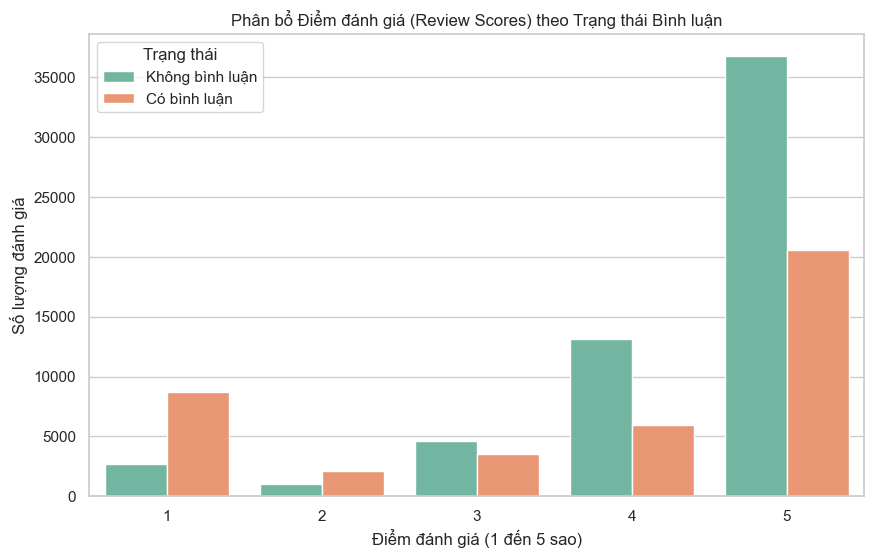

In [51]:
reviews['has_comment'] = reviews['review_comment_message'].notna().map({True: 'Có bình luận', False: 'Không bình luận'})
plt.figure(figsize=(10, 6))
sns.countplot(data=reviews, x='review_score', hue='has_comment', palette='Set2')
plt.title('Phân bổ Điểm đánh giá (Review Scores) theo Trạng thái Bình luận')
plt.xlabel('Điểm đánh giá (1 đến 5 sao)')
plt.ylabel('Số lượng đánh giá')
plt.legend(title='Trạng thái')
plt.show()

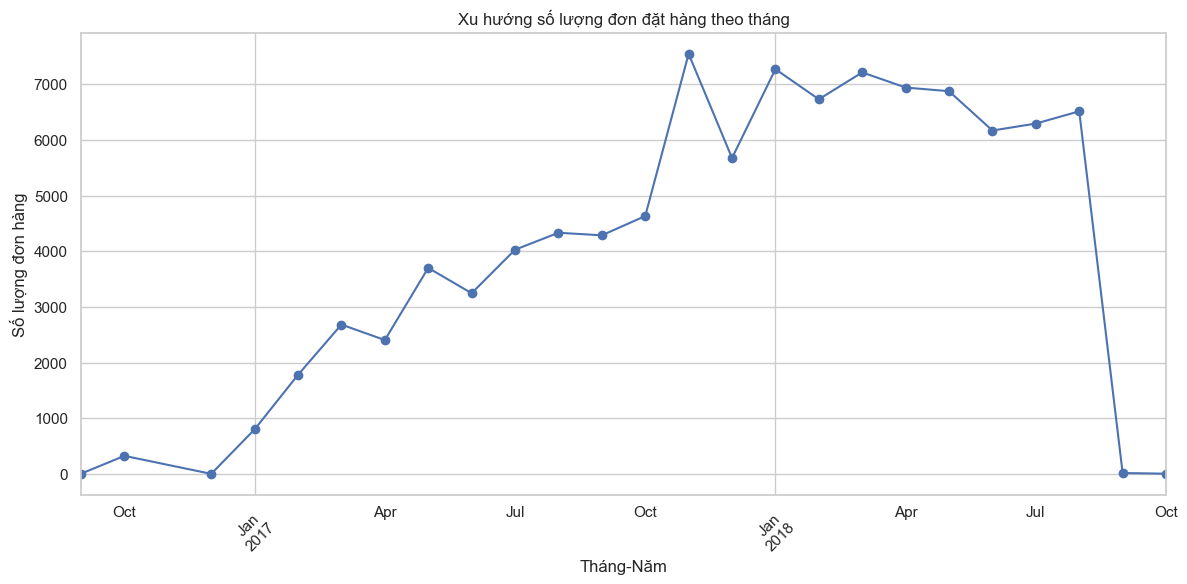

In [52]:
orders['order_month_year'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders.groupby('order_month_year')['order_id'].count()

plt.figure(figsize=(14, 6))
monthly_orders.plot(kind='line', marker='o', color='b')
plt.title('Xu hướng số lượng đơn đặt hàng theo tháng')
plt.xlabel('Tháng-Năm')
plt.ylabel('Số lượng đơn hàng')
plt.xticks(rotation=45)
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9128\2797550392.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


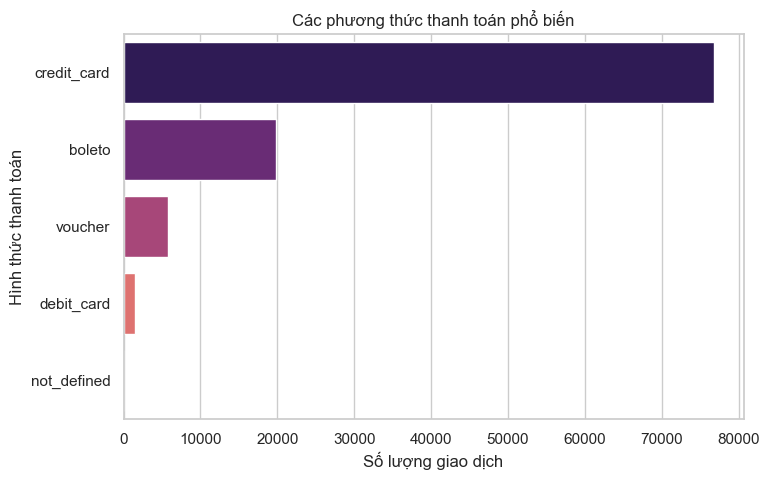

In [53]:
plt.figure(figsize=(8, 5))
# Dữ liệu thanh toán bao gồm: credit_card, boleto, voucher, debit_card
sns.barplot(
    y=payments['payment_type'].value_counts().index, 
    x=payments['payment_type'].value_counts().values, 
    palette='magma'
)
plt.title('Các phương thức thanh toán phổ biến')
plt.xlabel('Số lượng giao dịch')
plt.ylabel('Hình thức thanh toán')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9128\3088068412.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_categories.index, x=top_categories.values, palette='crest')


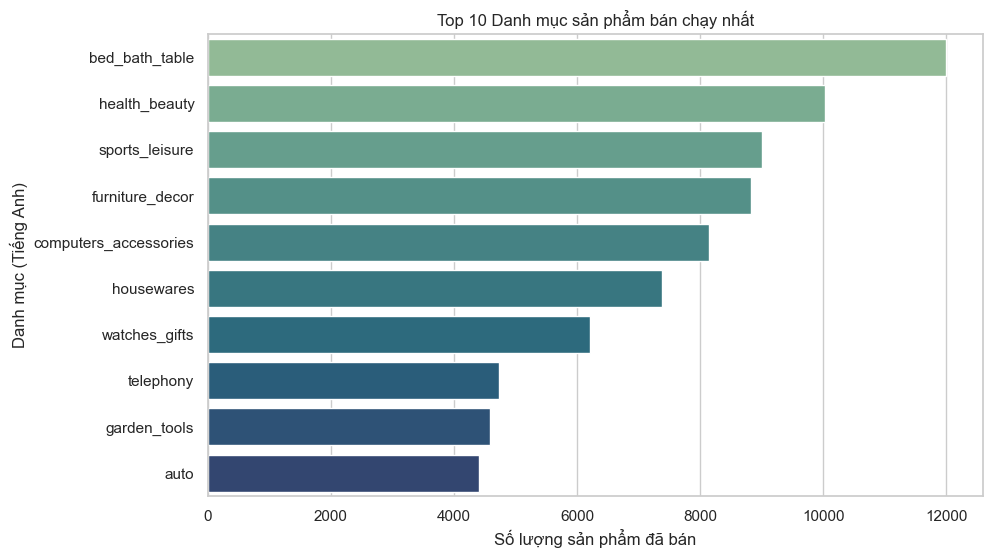

In [54]:
top_categories = df_master['product_category_name_english'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(y=top_categories.index, x=top_categories.values, palette='crest')
plt.title('Top 10 Danh mục sản phẩm bán chạy nhất')
plt.xlabel('Số lượng sản phẩm đã bán')
plt.ylabel('Danh mục (Tiếng Anh)')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9128\909898601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.index, y=top_states.values, palette='coolwarm')


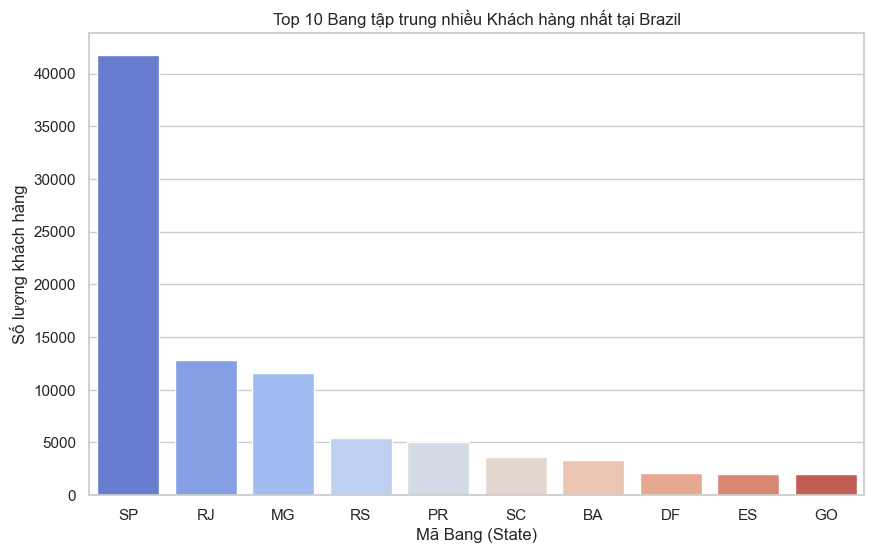

In [55]:
plt.figure(figsize=(10, 6))
top_states = customers['customer_state'].value_counts().head(10)
sns.barplot(x=top_states.index, y=top_states.values, palette='coolwarm')
plt.title('Top 10 Bang tập trung nhiều Khách hàng nhất tại Brazil')
plt.xlabel('Mã Bang (State)')
plt.ylabel('Số lượng khách hàng')
plt.show()

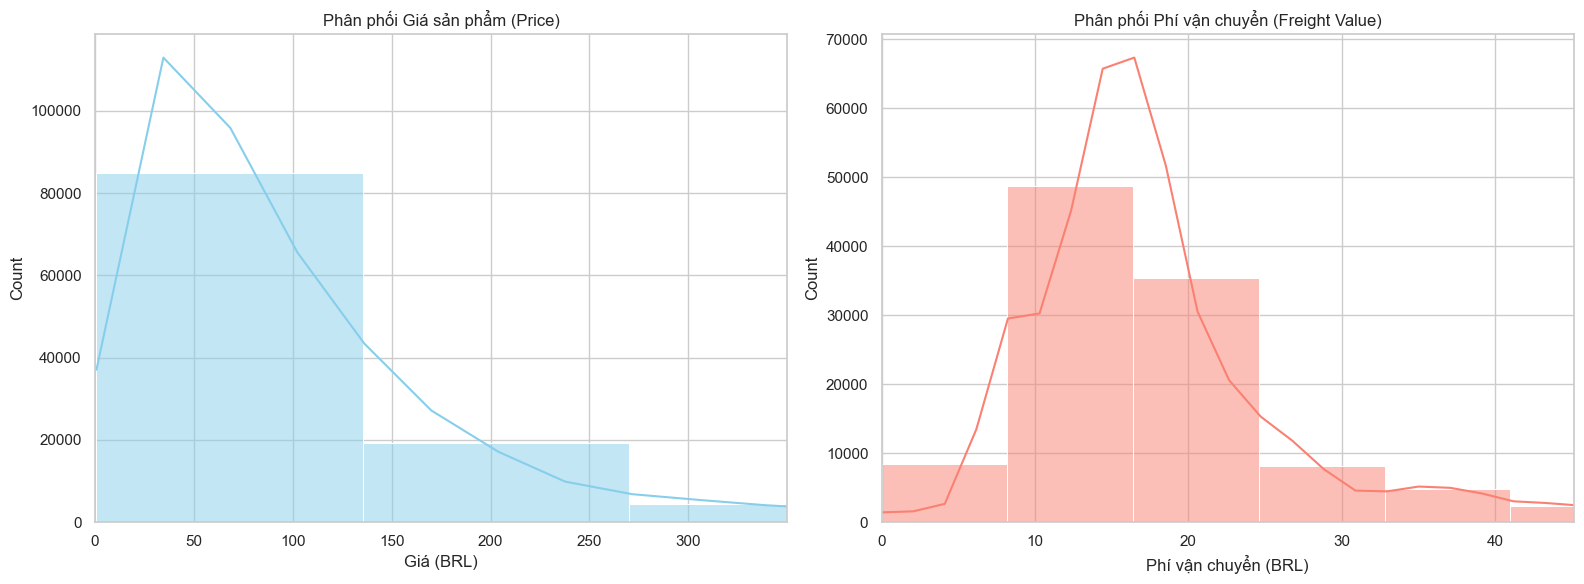

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(order_items['price'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối Giá sản phẩm (Price)')
axes[0].set_xlabel('Giá (BRL)')
axes[0].set_xlim(0, order_items['price'].quantile(0.95)) # Cắt ở 95th percentile để loại bỏ outlier làm lệch biểu đồ

sns.histplot(order_items['freight_value'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Phân phối Phí vận chuyển (Freight Value)')
axes[1].set_xlabel('Phí vận chuyển (BRL)')
axes[1].set_xlim(0, order_items['freight_value'].quantile(0.95))
plt.tight_layout()
plt.show()

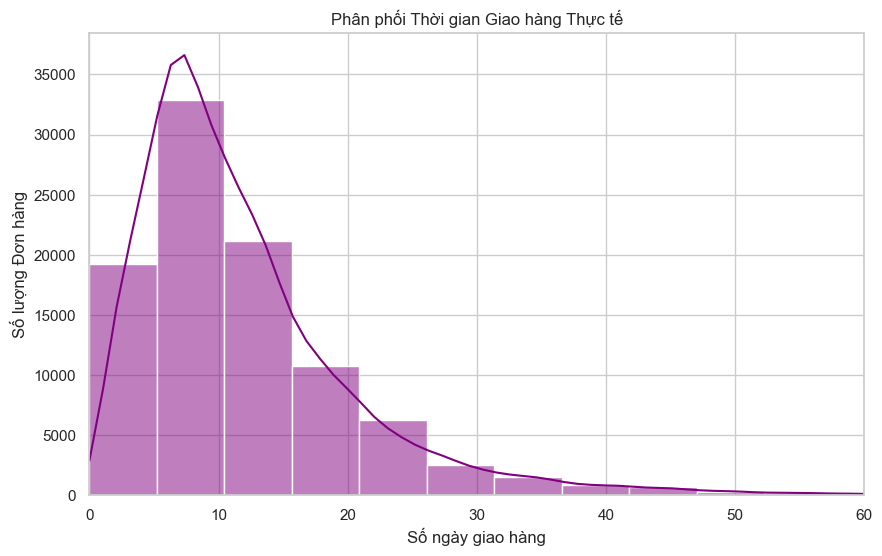

In [57]:
# Tính thời gian giao hàng = Ngày khách nhận hàng - Ngày đặt hàng
orders['delivery_time_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

plt.figure(figsize=(10, 6))
sns.histplot(orders['delivery_time_days'].dropna(), bins=40, kde=True, color='purple')
plt.title('Phân phối Thời gian Giao hàng Thực tế')
plt.xlabel('Số ngày giao hàng')
plt.ylabel('Số lượng Đơn hàng')
plt.xlim(0, 60) # Giới hạn trục x để biểu đồ dễ nhìn hơn
plt.show()

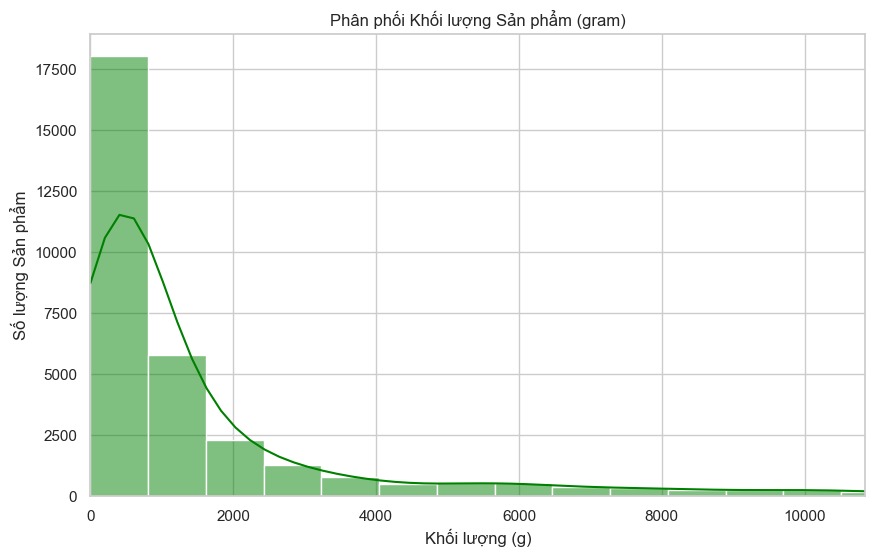

In [58]:
plt.figure(figsize=(10, 6))
sns.histplot(products['product_weight_g'].dropna(), bins=50, kde=True, color='green')
plt.title('Phân phối Khối lượng Sản phẩm (gram)')
plt.xlabel('Khối lượng (g)')
plt.ylabel('Số lượng Sản phẩm')
plt.xlim(0, products['product_weight_g'].quantile(0.95)) # Cắt ở 95th percentile [2]
plt.show()

In [59]:
geo_unique = geo.drop_duplicates(subset=['geolocation_zip_code_prefix'])
customers_geo = customers.merge(
    geo_unique, 
    left_on='customer_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix', 
    how='inner'
)
# Giới hạn xấp xỉ của lãnh thổ Brazil: Vĩ độ (Lat) từ -35 đến 5, Kinh độ (Lng) từ -74 đến -32
brazil_geo = customers_geo[
    (customers_geo['geolocation_lat'] <= 5) & 
    (customers_geo['geolocation_lat'] >= -35) & 
    (customers_geo['geolocation_lng'] <= -32) & 
    (customers_geo['geolocation_lng'] >= -74)
]

print(f"Số lượng khách hàng có tọa độ hợp lệ: {brazil_geo.shape}")

Số lượng khách hàng có tọa độ hợp lệ: (99146, 10)


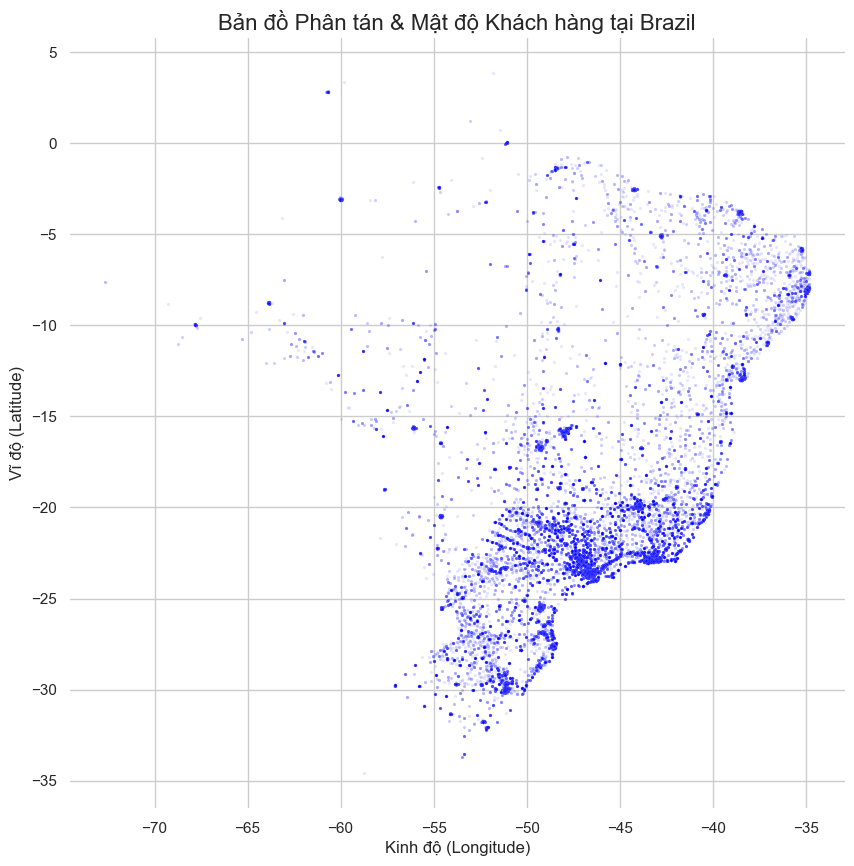

In [60]:
plt.figure(figsize=(10, 10))

# Vẽ scatter plot dựa trên kinh độ (x) và vĩ độ (y)
sns.scatterplot(
    x='geolocation_lng', 
    y='geolocation_lat', 
    data=brazil_geo, 
    alpha=0.1,    # Chỉnh độ trong suốt để tạo hiệu ứng mật độ
    s=5,          # Kích thước điểm ảnh nhỏ
    color='blue'  # Màu sắc điểm
)

plt.title('Bản đồ Phân tán & Mật độ Khách hàng tại Brazil', fontsize=16)
plt.xlabel('Kinh độ (Longitude)', fontsize=12)
plt.ylabel('Vĩ độ (Latitude)', fontsize=12)

# Xóa khung viền biểu đồ cho giống bản đồ thật hơn
sns.despine(left=True, bottom=True)
plt.show()

In [61]:
# Khởi tạo bản đồ nền với trung tâm là tọa độ của Brazil
# Tọa độ xấp xỉ vùng trung tâm: [-15.7801, -47.9292]
map_brazil = folium.Map(location=[-15.7801, -47.9292], zoom_start=4, tiles='CartoDB Positron')

# Chuẩn bị dữ liệu đầu vào cho HeatMap (List các cặp [vĩ độ, kinh độ])
heat_data = brazil_geo[['geolocation_lat', 'geolocation_lng']].values.tolist()

# Thêm lớp HeatMap vào bản đồ
HeatMap(heat_data, 
        radius=10,        # Bán kính tỏa nhiệt
        blur=7,           # Độ mờ 
        min_opacity=0.4   # Độ trong suốt tối thiểu
).add_to(map_brazil)

# Hiển thị bản đồ (Trong Jupyter/Colab, chỉ cần gọi tên biến)
map_brazil.save('customer_density_heatmap_brazil.html')